# Green Cart Ltd. — Q2 Performance Review

## 1. Project Overview

This project analyses Green Cart Ltd.'s Q2 business performance using customer, product, and sales data.

The analysis focuses on sales performance, customer behaviour, product performance, delivery reliability, and payment preferences. The objective is to transform the available operational data into actionable insights that can support marketing, logistics, and customer-engagement decisions.

## Business Questions

The analysis addresses the following questions:

1. Which product categories generate the most revenue, and in which regions?
2. Do discounts influence the quantity of products sold?
3. Which loyalty tier generates the greatest customer value?
4. Are particular regions experiencing higher delivery delays?
5. Do customer signup patterns relate to purchasing behaviour?

## Analytical Approach

The analysis follows an end-to-end data analytics workflow:

1. Load and inspect the source datasets
2. Assess data quality
3. Clean and standardise the datasets
4. Integrate customer, product, and sales information
5. Engineer relevant business features
6. Analyse business performance
7. Visualise key findings
8. Develop data-driven recommendations

## 2. Data Loading & Initial Inspection

In [1]:
# Import libries
# Core data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# set plotting standard
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# 2.1. Load source datasets

customer_df = pd.read_csv("customer_info.csv")
product_df = pd.read_csv("product_info.csv")
sales_df = pd.read_csv("sales_data.csv")

In [3]:
# 2.2. Create a concise dataset overview

datasets = {
    "Customer": customer_df,
    "Product": product_df,
    "Sales": sales_df
}

for name, df in datasets.items():
    print(f"{name} dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Customer dataset: 500 rows × 6 columns
Product dataset: 30 rows × 6 columns
Sales dataset: 3,000 rows × 10 columns


In [4]:
# 2.3. Inspect structure and missing values

for name, df in datasets.items():
    print(f"\n{name} dataset")
    display(df.head())
    display(df.dtypes)
    display(df.isna().sum())


Customer dataset


,customer_id,email,signup_date,gender,region,loyalty_tier
0,C00001,shaneramirez@gmail.com,26-04-25,Male,Central,Silver
1,C00002,jpeterson@bernard.com,11-08-24,Female,Central,gold
2,C00003,howardmaurice@yahoo.com,15-05-25,male,Central,gold
3,C00004,yherrera@arnold.org,14-06-25,FEMALE,Central,GOLD
4,C00005,janetwilliams@gmail.com,02-05-25,Male,West,bronze


customer_id     object
email           object
signup_date     object
gender          object
region          object
loyalty_tier    object
dtype: object

customer_id     3
email           6
signup_date     4
gender          4
region          3
loyalty_tier    2
dtype: int64


Product dataset


...

product_id       0
product_name     0
category         0
launch_date      0
base_price       0
supplier_code    0
dtype: int64


Sales dataset


,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,06-07-25,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,06-07-25,DELAYED,credit card,North,0.00
2,O202644,C00492,P0011,1,29.68,06-07-25,delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,06-07-25,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,06-07-25,DELAYED,Credit Card,West,0.20


order_id             object
customer_id          object
product_id           object
quantity             object
unit_price          float64
order_date           object
delivery_status      object
payment_method       object
region               object
discount_applied    float64
dtype: object

order_id              1
customer_id           2
product_id            5
quantity              3
unit_price            1
order_date            3
delivery_status       3
payment_method        3
region                0
discount_applied    517
dtype: int64

## 3. Data Quality Assessment & Cleaning

In [5]:
# 3.1 Customer Data initial quality assessment
# 3.1.1. Customer data quality assessment

customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   497 non-null    object
 1   email         494 non-null    object
 2   signup_date   496 non-null    object
 3   gender        496 non-null    object
 4   region        497 non-null    object
 5   loyalty_tier  498 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


In [6]:
customer_df.isna().sum().sort_values(ascending=False)

email           6
signup_date     4
gender          4
customer_id     3
region          3
loyalty_tier    2
dtype: int64

In [7]:
#  3.1.2. Remove records without a customer identifier

customer_df = customer_df.dropna(subset=["customer_id"]).copy()

### Customer ID

Records without a `customer_id` cannot be reliably linked to transactional data. These records are therefore excluded from the analysis.

In [8]:
# 3.1.3. Standardise Categorical fields
# standardise gender labels

customer_df['gender'] = (
    customer_df['gender']
    .astype('string')
    .str.strip()
    .str.lower()
    .replace({'femle': 'female'})
    .str.title()
)

In [9]:
# standardise loyality tier labels

customer_df['loyalty_tier'] = (
    customer_df['loyalty_tier']
    .astype('string')
    .str.strip()
    .str.lower()
    .str.title()
)

In [10]:
#  3.1.4. Handle missing categorical values
# preserve missing categorical information explicitly

customer_df['gender'] = customer_df['gender'].fillna('unknown')
customer_df['region'] = customer_df['region'].fillna('unspectified')
customer_df['loyalty_tier'] = customer_df['loyalty_tier'].fillna('None')

In [11]:
# 3.1.5 Parse signup dates properly
# Convert signup date to datetime

customer_df["signup_date"] = pd.to_datetime(
    customer_df["signup_date"],
    format="%d-%m-%y",
    errors="coerce"
)

In [12]:
customer_df["signup_date"].isna().sum()

np.int64(4)

In [13]:
# 3.1.6. Final customer-data validation
# check the cleaned customer dataset

print(f"Rows: {len(customer_df):,}")
print(f"Columns: {customer_df.shape[1]}")

display(customer_df.head())

display(customer_df.isna().sum())

Rows: 497
Columns: 6


,customer_id,email,signup_date,gender,region,loyalty_tier
0,C00001,shaneramirez@gmail.com,2025-04-26,Male,Central,Silver
1,C00002,jpeterson@bernard.com,2024-08-11,Female,Central,Gold
2,C00003,howardmaurice@yahoo.com,2025-05-15,Male,Central,Gold
3,C00004,yherrera@arnold.org,2025-06-14,Female,Central,Gold
4,C00005,janetwilliams@gmail.com,2025-05-02,Male,West,Bronze


customer_id     0
email           6
signup_date     4
gender          0
region          0
loyalty_tier    0
dtype: int64

In [14]:
# 3.1.7. Confirm customer IDs are unique

customer_df["customer_id"].duplicated().sum()

np.int64(0)

## 3.2 Product Dataset

In [15]:
# 3.2.1. Quality assessment
# product data quality assessment

product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     30 non-null     object 
 1   product_name   30 non-null     object 
 2   category       30 non-null     object 
 3   launch_date    30 non-null     object 
 4   base_price     30 non-null     float64
 5   supplier_code  30 non-null     object 
dtypes: float64(1), object(5)
memory usage: 1.5+ KB


In [16]:
display(product_df.isna().sum())

product_id       0
product_name     0
category         0
launch_date      0
base_price       0
supplier_code    0
dtype: int64

In [17]:
display(product_df.nunique().sort_values())

category          5
launch_date      29
product_name     30
product_id       30
base_price       30
supplier_code    30
dtype: int64

In [18]:
# 3.2.2. Check product ID uniqueness

product_df["product_id"].duplicated().sum()

np.int64(0)

In [19]:
# 3.2.3. Standardise categorical fields

product_df["category"] = (
    product_df["category"]
    .astype("string")
    .str.strip()
    .str.title()
)

product_df["supplier_code"] = (
    product_df["supplier_code"]
    .astype("string")
    .str.strip()
    .str.upper()
)

product_df["product_name"] = (
    product_df["product_name"]
    .astype("string")
    .str.strip()
)

In [20]:
# 3.2.4. Convert launch date

product_df["launch_date"] = pd.to_datetime(
    product_df["launch_date"],
    format="%d-%m-%y",
    errors="coerce"
)

In [21]:
product_df["launch_date"].isna().sum()

np.int64(0)

In [22]:
# 3.2.5. Validate numerical fields

product_df['base_price'].describe()

count    30.000000
mean     22.844333
std      10.269165
min       6.080000
25%      14.812500
50%      23.230000
75%      31.745000
max      39.210000
Name: base_price, dtype: float64

In [23]:
(product_df['base_price'] <= 0).sum()

np.int64(0)

In [24]:
# 3.2.6 Final product-data validation

print(f"Rows: {len(product_df):,}")
print(f"Columns: {product_df.shape[1]}")

display(product_df.head())

display(product_df.isna().sum())

print(
    "Duplicate product IDs:",
    product_df["product_id"].duplicated().sum()
)

Rows: 30
Columns: 6


,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,2025-03-11,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,2024-08-18,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745
3,P0004,Kitchen Product 82,Kitchen,2025-04-19,9.13,S589
4,P0005,Personal Care Product 1,Personal Care,2024-10-20,31.10,S559


product_id       0
product_name     0
category         0
launch_date      0
base_price       0
supplier_code    0
dtype: int64

Duplicate product IDs: 0


## Sales Dataset

In [25]:
# 3.3.1. sales data quality assessment
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2999 non-null   object 
 1   customer_id       2998 non-null   object 
 2   product_id        2995 non-null   object 
 3   quantity          2997 non-null   object 
 4   unit_price        2999 non-null   float64
 5   order_date        2997 non-null   object 
 6   delivery_status   2997 non-null   object 
 7   payment_method    2997 non-null   object 
 8   region            3000 non-null   object 
 9   discount_applied  2483 non-null   float64
dtypes: float64(2), object(8)
memory usage: 234.5+ KB


In [26]:
display(sales_df.isna().sum().sort_values(ascending=False))

discount_applied    517
product_id            5
payment_method        3
delivery_status       3
order_date            3
quantity              3
customer_id           2
order_id              1
unit_price            1
region                0
dtype: int64

In [27]:
display(sales_df.describe(include='all'))

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
count,2999,2998,2995,2997,2999.000000,2997,2997,2997,3000,2483.000000
unique,2997,499,30,7,NaN,1,7,5,6,NaN
top,O515400,C00385,P0010,2,NaN,06-07-25,Delivered,Bank Transfer,North,NaN
freq,2,15,122,635,NaN,2997,637,780,605,NaN
mean,NaN,NaN,NaN,NaN,28.945388,NaN,NaN,NaN,NaN,0.100262
std,NaN,NaN,NaN,NaN,12.085893,NaN,NaN,NaN,NaN,0.069987
min,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,18.830000,NaN,NaN,NaN,NaN,0.050000
50%,NaN,NaN,NaN,NaN,28.630000,NaN,NaN,NaN,NaN,0.100000
75%,NaN,NaN,NaN,NaN,39.640000,NaN,NaN,NaN,NaN,0.150000


In [28]:
# 3.3.2. Check order ID uniqueness

sales_df["order_id"].duplicated().sum()

np.int64(2)

In [29]:
# 3.3.3. Check customer and product references

print("Missing customer IDs:", sales_df["customer_id"].isna().sum())
print("Missing product IDs:", sales_df["product_id"].isna().sum())

Missing customer IDs: 2
Missing product IDs: 5


In [30]:
# 3.3.4 Investigate duplicate order
# Inspect duplicate order IDs

duplicate_orders = sales_df[
    sales_df["order_id"].duplicated(keep=False)
].sort_values("order_id")

display(duplicate_orders)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
156,O515400,C00103,P0024,4,44.15,06-07-25,delivered,PayPal,East,0.15
1461,O515400,C00389,P0027,2,22.04,06-07-25,Delayed,PayPal,North,0.05
793,O916245,C00390,P0010,1,24.57,06-07-25,Delayed,PayPal,South,0.10
2712,O916245,C00070,P0011,3,20.83,06-07-25,Delayed,Bank Transfer,West,0.05


In [31]:
# Compare the duplicated order records

duplicate_orders.groupby("order_id").size()

order_id
O515400    2
O916245    2
dtype: int64

In [32]:
#3.3.5. Inspect missing customer references
# Inspect sales records with missing customer IDs

missing_customer = sales_df[
    sales_df["customer_id"].isna()
]

display(missing_customer)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
851,O663482,NaN,P0029,3,18.89,06-07-25,Cancelled,PayPal,West,0.05
1707,O735004,NaN,P0017,2,12.18,06-07-25,delivered,Bank Transfer,Central,NaN


In [33]:
# 3.3.6. Inspect missing product references
# Inspect sales records with missing product IDs

missing_product = sales_df[
    sales_df["product_id"].isna()
]

display(missing_product)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
569,O711887,C00125,NaN,5,36.65,06-07-25,Cancelled,Bank Transfer,South,0.15
613,O231318,C00251,NaN,5,47.51,06-07-25,Delivered,PayPal,West,0.20
1267,O327646,C00451,NaN,4,29.16,06-07-25,Delayed,credit card,West,0.15
1841,O218065,C00324,NaN,5,25.61,06-07-25,Delayed,PayPal,North,0.20
2803,O140946,C00251,NaN,3,22.20,06-07-25,Delivered,PayPal,East,0.05


In [34]:
# 3.3.7. Check if sales references are valid for customers and products

invalid_customers = sales_df[
    sales_df["customer_id"].notna() &
    ~sales_df["customer_id"].isin(customer_df["customer_id"])
]

invalid_products = sales_df[
    sales_df["product_id"].notna() &
    ~sales_df["product_id"].isin(product_df["product_id"])
]

print("Sales with invalid customer references:", len(invalid_customers))
print("Sales with invalid product references:", len(invalid_products))

Sales with invalid customer references: 24
Sales with invalid product references: 0


### Data Quality Findings

The sales dataset contains several referential-integrity issues that require consideration before analysis.

- Two `order_id` values occur more than once, but the associated records contain different customers, products and transaction details. These records are therefore retained rather than treated as duplicate transactions.
- Five transactions have missing `product_id` values. These records retain transaction-level information but cannot be attributed to a specific product or category.
- Two transactions have missing `customer_id` values and therefore cannot be attributed to a specific customer.
- Twenty-four transactions contain customer IDs that do not match the cleaned customer reference table.
- No non-null product IDs reference products outside the product master dataset.

These issues will be retained as documented data-quality limitations and handled according to the requirements of each subsequent analysis.

In [35]:
# Inspect invalid customer references

display(
    invalid_customers[
        ['order_id','customer_id','product_id','quantity','unit_price','order_date','delivery_status','region','discount_applied']
    ].sort_values('customer_id')
)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,region,discount_applied
2963,O302550,C00254,P0020,1,15.28,06-07-25,Cancelled,West,0.20
186,O542189,C00254,P0019,2,11.68,06-07-25,DELAYED,Central,0.15
2674,O717096,C00254,P0027,1,44.12,06-07-25,Delivered,North,0.10
2516,O982650,C00254,P0008,1,24.92,06-07-25,DELAYED,Central,NaN
2063,O337369,C00254,P0017,5,30.19,06-07-25,delivered,Central,0.00
1866,O505694,C00254,P0023,3,20.80,06-07-25,Cancelled,East,0.05
2780,O310604,C00372,P0018,2,17.65,06-07-25,delivered,South,0.05
2579,O632407,C00372,P0023,3,24.61,06-07-25,Delivered,East,NaN
1861,O396282,C00372,P0003,2,33.08,06-07-25,DELAYED,South,0.20
1832,O975220,C00372,P0016,5,22.07,06-07-25,DELAYED,East,0.10


In [36]:
# Identify the customer IDs referenced by sales but absent from customer data

invalid_customer_ids = (
    sales_df.loc[
        sales_df['customer_id'].notna() &
        ~sales_df['customer_id'].isin(customer_df['customer_id']),
        'customer_id'
    ]
    .drop_duplicates()
    .sort_values()
)

display(invalid_customer_ids)

186    C00254
80     C00372
392    C00471
Name: customer_id, dtype: object

In [37]:
# Inspect original dataset for IDs

raw_customer_df = pd.read_csv("customer_info.csv")

raw_customer_df[
    raw_customer_df["customer_id"].isin(
        ["C00254", "C00372", "C00471"]
    )
]

,customer_id,email,signup_date,gender,region,loyalty_tier


### Data Quality Summary

The datasets were cleaned and validated for missing values, duplicates, data types, and consistency.

A total of **24 sales records** reference **3 customer IDs** that are not present in the customer dataset. These records were retained for transaction-level analysis but excluded where customer-level information was required.

Other missing values were handled according to their analytical relevance, without imputing unsupported customer information.

In [38]:
# 3.4.1 - Convert order date
# Convert order date to datetime

sales_df["order_date"] = pd.to_datetime(
    sales_df["order_date"],
    format="%d-%m-%y",
    errors="coerce"
)

In [39]:
# verify
sales_df["order_date"].isna().sum()

np.int64(3)

In [40]:
# 3.5.1 - Convert quantity to numeric

sales_df["quantity"] = pd.to_numeric(
    sales_df["quantity"],
    errors="coerce"
)

In [41]:
#3.4.3 - validate qauntity
# Check quantity

sales_df["quantity"].describe()

count    2995.000000
mean        3.002337
std         1.408176
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: quantity, dtype: float64

In [42]:
# Check for non-positive quantities

(sales_df["quantity"] <= 0).sum()

np.int64(0)

In [43]:
# Check missing quantities

sales_df["quantity"].isna().sum()


np.int64(5)

In [44]:
# 3.6. - Validate unit price
# Check unit price datatype

sales_df["unit_price"].dtype

dtype('float64')

In [45]:
# 3.6.2 - Convert unit price to numeric

sales_df["unit_price"] = pd.to_numeric(
    sales_df["unit_price"],
    errors="coerce"
)

In [46]:
# Validate unit price

sales_df["unit_price"].describe()

count    2999.000000
mean       28.945388
std        12.085893
min         8.000000
25%        18.830000
50%        28.630000
75%        39.640000
max        49.990000
Name: unit_price, dtype: float64

In [47]:
# Check for non-positive prices

(sales_df["unit_price"] <= 0).sum()

np.int64(0)

In [48]:
# 3.6.3 - Check missing unit prices

sales_df["unit_price"].isna().sum()

np.int64(1)

In [49]:
# 3.7 - Discount
# Check discount values

sales_df["discount_applied"].value_counts(dropna=False).sort_index()

discount_applied
0.00    479
0.05    505
0.10    506
0.15    510
0.20    483
NaN     517
Name: count, dtype: int64

In [50]:
# Check discount range

sales_df["discount_applied"].describe()

count    2483.000000
mean        0.100262
std         0.069987
min         0.000000
25%         0.050000
50%         0.100000
75%         0.150000
max         0.200000
Name: discount_applied, dtype: float64

**Discount data quality:** 2,483 transactions contain recorded discount values ranging from 0% to 20%, while 517 transactions have missing discount information. Missing values are retained as `NaN` until their treatment is established for the relevant analysis.

In [51]:
# 3.8 Standardise delivery status

sales_df["delivery_status"] = (
    sales_df["delivery_status"]
    .astype("string")
    .str.strip()
    .str.title()
)

In [52]:
sales_df["delivery_status"].value_counts(dropna=False)

delivery_status
Delivered    1231
Delayed      1173
Cancelled     591
<NA>            3
Delrd           1
Delyd           1
Name: count, dtype: Int64

In [53]:
# 3.8.2 - Inspect non-standard delivery statuses

sales_df[
    ~sales_df["delivery_status"].isin(
        ["Delivered", "Delayed", "Cancelled"]
    )
][["order_id", "delivery_status"]]

,order_id,delivery_status
398,O169606,Delrd
493,O779073,Delyd
601,O112478,<NA>
733,O697006,<NA>
1124,O239188,<NA>


In [54]:
# 3.8.3 - Correcting non-standard status
# Correct identifiable delivery-status labels

sales_df["delivery_status"] = sales_df["delivery_status"].replace({
    "Delrd": "Delivered",
    "Delyd": "Delayed"
})

In [55]:
# Validate delivery status

sales_df["delivery_status"].value_counts(dropna=False)

delivery_status
Delivered    1232
Delayed      1174
Cancelled     591
<NA>            3
Name: count, dtype: Int64

In [56]:
# 3.9 - Payment Method
# 3.9.1 Inspect payment methods

sales_df["payment_method"].value_counts(dropna=False)

payment_method
Bank Transfer    780
PayPal           763
Credit Card      735
credit card      718
NaN                3
bank transfr       1
Name: count, dtype: int64

In [57]:
# 3.9.2 - Standardise payment method

sales_df["payment_method"] = (
    sales_df["payment_method"]
    .astype("string")
    .str.strip()
    .str.title()
)

In [58]:
# Correct payment-method typo

sales_df["payment_method"] = sales_df["payment_method"].replace({
    "Bank Transfr": "Bank Transfer"
})

In [59]:
# Validate payment methods

sales_df["payment_method"].value_counts(dropna=False)

payment_method
Credit Card      1453
Bank Transfer     781
Paypal            763
<NA>                3
Name: count, dtype: Int64

In [60]:
# Standardise PayPal label

sales_df["payment_method"] = sales_df["payment_method"].replace({
    "Paypal": "PayPal"
})

In [61]:
sales_df["payment_method"].value_counts(dropna=False)

payment_method
Credit Card      1453
Bank Transfer     781
PayPal            763
<NA>                3
Name: count, dtype: Int64

In [62]:
# 3.10 - Region
# 3.10.1 Inspect region values

sales_df["region"].value_counts(dropna=False)

region
North      605
Central    603
East       602
South      596
West       593
nrth         1
Name: count, dtype: int64

In [63]:
# 3.10.2 - Correct region typo

sales_df["region"] = sales_df["region"].replace({
    "nrth": "North"
})

In [64]:
# Validate region

sales_df["region"].value_counts(dropna=False)

region
North      606
Central    603
East       602
South      596
West       593
Name: count, dtype: int64

In [65]:
# 3.11 - Final sales-data validation

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2999 non-null   object        
 1   customer_id       2998 non-null   object        
 2   product_id        2995 non-null   object        
 3   quantity          2995 non-null   float64       
 4   unit_price        2999 non-null   float64       
 5   order_date        2997 non-null   datetime64[ns]
 6   delivery_status   2997 non-null   string        
 7   payment_method    2997 non-null   string        
 8   region            3000 non-null   object        
 9   discount_applied  2483 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(4), string(2)
memory usage: 234.5+ KB


In [66]:
sales_df.isna().sum()

order_id              1
customer_id           2
product_id            5
quantity              5
unit_price            1
order_date            3
delivery_status       3
payment_method        3
region                0
discount_applied    517
dtype: int64

In [67]:
sales_df.shape

(3000, 10)

### Sales Data Validation

The cleaned sales dataset contains 3,000 records and 10 fields. Data types,
categorical inconsistencies, missing values, duplicate order identifiers, and
referential integrity were assessed. Remaining missing values are retained
where the available data does not support reliable imputation.

## 4. Data Integration

In [68]:
# 4.0.1 Check integration keys

print("Customer IDs:", customer_df["customer_id"].nunique())
print("Product IDs:", product_df["product_id"].nunique())

print("Sales customer IDs:", sales_df["customer_id"].nunique())
print("Sales product IDs:", sales_df["product_id"].nunique())

Customer IDs: 497
Product IDs: 30
Sales customer IDs: 499
Sales product IDs: 30


In [69]:
# Check customer and product key matches

print(
    "Matching customers:",
    sales_df["customer_id"].isin(customer_df["customer_id"]).sum()
)

print(
    "Matching products:",
    sales_df["product_id"].isin(product_df["product_id"]).sum()
)

Matching customers: 2974
Matching products: 2995


In [70]:
# 4.0.2 Merge customer data

integrated_sales_df = sales_df.merge(
    customer_df,
    on="customer_id",
    how="left"
)

In [71]:
# Check integrated dataset

integrated_sales_df.shape

(3000, 15)

In [72]:
# 4.0.3 Validate customer merge
#Check customer merge

integrated_sales_df["email"].isna().sum()

np.int64(57)

In [73]:
# Validate customer merge

integrated_sales_df["customer_id"].isna().sum()

np.int64(2)

In [74]:
# Check unmatched customer references

integrated_sales_df[
    integrated_sales_df["customer_id"].isin(["C00254", "C00372", "C00471"])
]["customer_id"].value_counts()

customer_id
C00471    11
C00372     7
C00254     6
Name: count, dtype: int64

In [75]:
# 4.0.4 Merge product data

integrated_sales_df = integrated_sales_df.merge(
    product_df,
    on="product_id",
    how="left"
)

In [76]:
# Check integrated dataset

integrated_sales_df.shape

(3000, 20)

In [77]:
# 4.0.5 Final integration validation

integrated_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2999 non-null   object        
 1   customer_id       2998 non-null   object        
 2   product_id        2995 non-null   object        
 3   quantity          2995 non-null   float64       
 4   unit_price        2999 non-null   float64       
 5   order_date        2997 non-null   datetime64[ns]
 6   delivery_status   2997 non-null   string        
 7   payment_method    2997 non-null   string        
 8   region_x          3000 non-null   object        
 9   discount_applied  2483 non-null   float64       
 10  email             2943 non-null   object        
 11  signup_date       2946 non-null   datetime64[ns]
 12  gender            2974 non-null   string        
 13  region_y          2974 non-null   object        
 14  loyalty_tier      2974 n

In [78]:
integrated_sales_df.isna().sum()

order_id              1
customer_id           2
product_id            5
quantity              5
unit_price            1
order_date            3
delivery_status       3
payment_method        3
region_x              0
discount_applied    517
email                57
signup_date          54
gender               26
region_y             26
loyalty_tier         26
product_name          5
category              5
launch_date           5
base_price            5
supplier_code         5
dtype: int64

In [79]:
# 4.0.6 Rename duplicated region fields

integrated_sales_df = integrated_sales_df.rename(columns={
    "region_x": "order_region",
    "region_y": "customer_region"
})

In [80]:
# Check region fields

integrated_sales_df[
    ["order_region", "customer_region"]
].head()

,order_region,customer_region
0,Central,North
1,North,North
2,North,Central
3,Central,Central
4,West,Central


**Region fields:** The integrated dataset contains both `order_region` and
`customer_region`. These represent different attributes and are retained
separately rather than treating differences between them as data errors.

# 5. Feature Engineering

## 5.0.1 - Calculate revenue
Revenue = quantity × unit price × (1 − discount)

In [81]:
# 5.0.1 Calculate revenue

integrated_sales_df["revenue"] = (
    integrated_sales_df["quantity"]
    * integrated_sales_df["unit_price"]
    * (1 - integrated_sales_df["discount_applied"])
)

In [82]:
# Check revenue

integrated_sales_df["revenue"].describe()

count    2479.000000
mean       78.368201
std        52.376181
min         6.800000
25%        35.838000
50%        64.880000
75%       113.965000
max       249.350000
Name: revenue, dtype: float64

In [83]:
# Check missing revenue

integrated_sales_df["revenue"].isna().sum()

np.int64(521)

In [84]:
# 5.0.2 — Check the components of missing revenue
# Check missing revenue against key inputs

integrated_sales_df[
    integrated_sales_df["revenue"].isna()
][["quantity", "unit_price", "discount_applied"]].isna().sum()

quantity              5
unit_price            1
discount_applied    517
dtype: int64

In [85]:
# 5.0.3 Create order week

integrated_sales_df["order_week"] = (
    integrated_sales_df["order_date"].dt.isocalendar().week
)

In [86]:
# Check order week

integrated_sales_df["order_week"].value_counts().sort_index()

order_week
27    2997
Name: count, dtype: Int64

In [87]:
# 5.0.4 - Validate order-week variation
# Check number of unique order weeks

integrated_sales_df["order_week"].nunique()

1

In [88]:
# Remove non-informative feature

integrated_sales_df.drop(columns="order_week", inplace=True)

In [89]:
# 5.0.5 Inspect base price

integrated_sales_df["base_price"].describe()

count    2995.000000
mean       22.891119
std        10.031630
min         6.080000
25%        14.670000
50%        23.050000
75%        31.960000
max        39.210000
Name: base_price, dtype: float64

In [90]:
# 5.0.6 Create price bands

integrated_sales_df["price_band"] = pd.cut(
    integrated_sales_df["base_price"],
    bins=[-float("inf"), 14.67, 31.96, float("inf")],
    labels=["Low", "Medium", "High"]
)

In [91]:
# Check price bands

integrated_sales_df["price_band"].value_counts(dropna=False)

price_band
Medium    1506
Low        783
High       706
NaN          5
Name: count, dtype: int64

In [92]:
# 5.0.7 Check dates for days_to_order

integrated_sales_df[
    ["signup_date", "order_date"]
].head()

,signup_date,order_date
0,2024-09-08,2025-07-06
1,2024-08-06,2025-07-06
2,2024-09-25,2025-07-06
3,2024-07-28,2025-07-06
4,2024-09-18,2025-07-06


In [93]:
# 5.0.8 Calculate days from signup to order

integrated_sales_df["days_to_order"] = (
    integrated_sales_df["order_date"]
    - integrated_sales_df["signup_date"]
).dt.days

In [94]:
# Check days to order

integrated_sales_df["days_to_order"].describe()

count    2943.000000
mean      192.527693
std       102.254454
min         0.000000
25%       112.000000
50%       195.000000
75%       279.000000
max       365.000000
Name: days_to_order, dtype: float64

In [95]:
# Check for negative days to order

(integrated_sales_df["days_to_order"] < 0).sum()

np.int64(0)

In [96]:
# 5.0.9 Extract email domain

integrated_sales_df["email_domain"] = (
    integrated_sales_df["email"]
    .str.split("@")
    .str[-1]
)

In [97]:
# Check email domains

integrated_sales_df["email_domain"].value_counts(dropna=False)

email_domain
yahoo.com                577
hotmail.com              468
gmail.com                466
NaN                       57
young.com                 17
                        ... 
nguyen-ellis.com           2
hernandez.com              2
walker-velasquez.info      2
rivera-kennedy.com         1
ramos.com                  1
Name: count, Length: 222, dtype: int64

In [98]:
# Standardise email domains

integrated_sales_df["email_domain"] = (
    integrated_sales_df["email"]
    .str.strip()
    .str.lower()
    .str.split("@")
    .str[-1]
)

In [99]:
# 5.0.10 Create late-delivery indicator

integrated_sales_df["is_late"] = (
    integrated_sales_df["delivery_status"] == "Delayed"
)

In [100]:
integrated_sales_df["is_late"].value_counts(dropna=False)

is_late
False    1823
True     1174
<NA>        3
Name: count, dtype: Int64

In [101]:
# Validate is_late
# Check delayed-order rate

integrated_sales_df["is_late"].value_counts(normalize=True, dropna=True)

is_late
False    0.608275
True     0.391725
Name: proportion, dtype: Float64

In [102]:
# underperforming
# 5.0.11 Inspect quantity distribution

integrated_sales_df["quantity"].describe()

count    2995.000000
mean        3.002337
std         1.408176
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: quantity, dtype: float64

In [103]:
# Inspect discount distribution

integrated_sales_df["discount_applied"].describe()

count    2483.000000
mean        0.100262
std         0.069987
min         0.000000
25%         0.050000
50%         0.100000
75%         0.150000
max         0.200000
Name: discount_applied, dtype: float64

In [104]:
# 5.0.12 Check underperformance conditions

low_quantity = integrated_sales_df["quantity"] <= 2
high_discount = integrated_sales_df["discount_applied"] >= 0.15
late_delivery = integrated_sales_df["is_late"] == True

print("Low quantity:", low_quantity.sum())
print("High discount:", high_discount.sum())
print("Late delivery:", late_delivery.sum())
print("All three conditions:", (low_quantity & high_discount & late_delivery).sum())

Low quantity: 1210
High discount: 993
Late delivery: 1174
All three conditions: 154


In [105]:
# 5.0.13 Create underperforming flag

integrated_sales_df["underperforming"] = (
    low_quantity
    & high_discount
    & late_delivery
)

In [106]:
# Check underperforming orders

integrated_sales_df["underperforming"].value_counts()

underperforming
False    2845
True      154
Name: count, dtype: Int64

In [107]:
# Check missing underperforming values

integrated_sales_df["underperforming"].value_counts(dropna=False)

underperforming
False    2845
True      154
<NA>        1
Name: count, dtype: Int64

## 6.0 Exploratory & Business Analysis

In [108]:
# 6.1 Product & Category Performance
# 6.1.1 Category performance

category_performance = (
    integrated_sales_df
    .groupby("category", dropna=False)
    .agg(
        orders=("order_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
)

category_performance

,orders,quantity_sold,revenue
category,,,
Cleaning,1204,3584.0,75377.0940
Storage,577,1730.0,38198.2375
Outdoors,508,1525.0,32974.5040
Kitchen,403,1229.0,25702.1115
Personal Care,302,902.0,21412.1665
<NA>,5,22.0,610.6565


<Axes: title={'center': 'Revenue by Product Category'}, xlabel='Category', ylabel='Revenue (£)'>

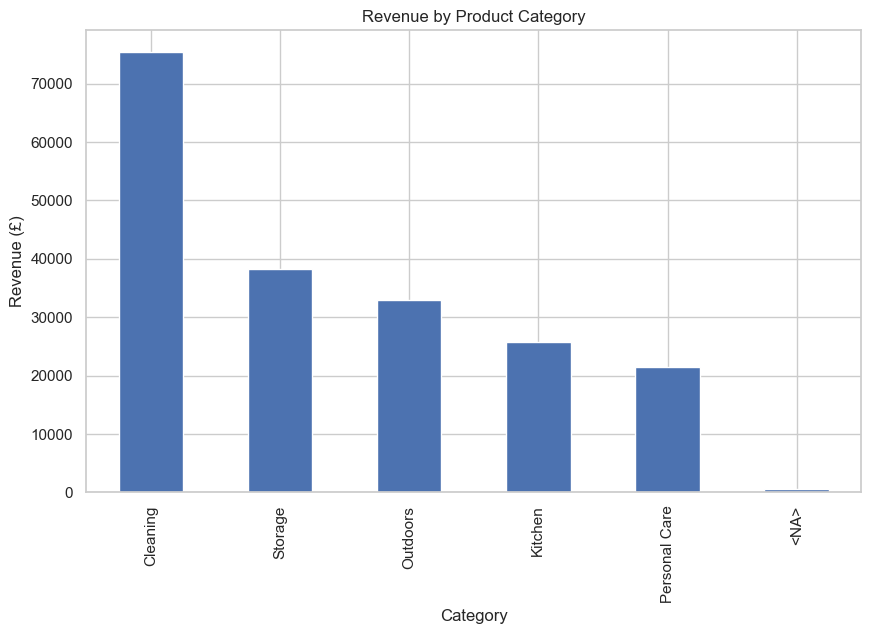

In [109]:
# 6.1.2 Category revenue

category_performance["revenue"].dropna().plot(
    kind="bar",
    title="Revenue by Product Category",
    ylabel="Revenue (£)",
    xlabel="Category"
)

In [110]:
# 6.1.3 Revenue contribution by category

category_performance["revenue_share"] = (
    category_performance["revenue"]
    / category_performance["revenue"].sum()
    * 100
)

category_performance[["revenue", "revenue_share"]]

,revenue,revenue_share
category,,
Cleaning,75377.0940,38.799219
Storage,38198.2375,19.661965
Outdoors,32974.5040,16.973127
Kitchen,25702.1115,13.229773
Personal Care,21412.1665,11.021589
<NA>,610.6565,0.314326


In [111]:
# 6.1.4 Revenue share excluding unknown category

known_category = category_performance.dropna(subset=["revenue"]).copy()

known_category = known_category[
    known_category.index.notna()
]

known_category["revenue_share"] = (
    known_category["revenue"]
    / known_category["revenue"].sum()
    * 100
)

known_category[["revenue", "revenue_share"]]

,revenue,revenue_share
category,,
Cleaning,75377.0940,38.921560
Storage,38198.2375,19.723963
Outdoors,32974.5040,17.026646
Kitchen,25702.1115,13.271489
Personal Care,21412.1665,11.056342


In [112]:
# 6.1.4 Regional performance

region_performance = (
    integrated_sales_df
    .groupby("order_region", dropna=False)
    .agg(
        orders=("order_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
)

region_performance

,orders,quantity_sold,revenue
order_region,,,
South,596,1831.0,40323.6650
West,592,1795.0,39933.2360
East,602,1789.0,39133.2820
North,606,1776.0,37474.6555
Central,603,1801.0,37409.9315


In [113]:
# 6.1.5 Average revenue per order by region

region_performance["avg_revenue_per_order"] = (
    region_performance["revenue"]
    / region_performance["orders"]
)

region_performance[
    ["orders", "revenue", "avg_revenue_per_order"]
]

,orders,revenue,avg_revenue_per_order
order_region,,,
South,596,40323.6650,67.657156
West,592,39933.2360,67.454791
East,602,39133.2820,65.005452
North,606,37474.6555,61.839366
Central,603,37409.9315,62.039687


<Axes: title={'center': 'Average Revenue per Order by Region'}, xlabel='Average Revenue (£)', ylabel='Region'>

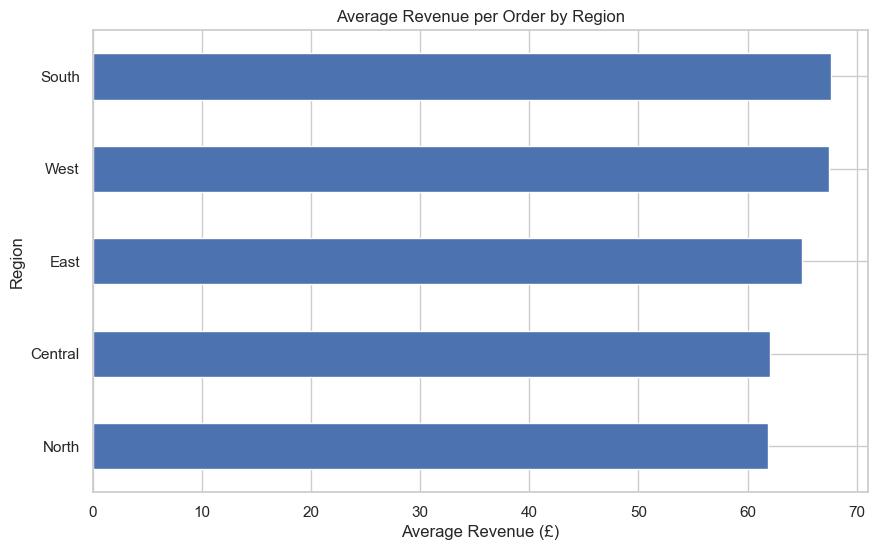

In [114]:
# 6.1.6 Average revenue per order by region

region_performance["avg_revenue_per_order"].sort_values().plot(
    kind="barh",
    title="Average Revenue per Order by Region",
    xlabel="Average Revenue (£)",
    ylabel="Region"
)

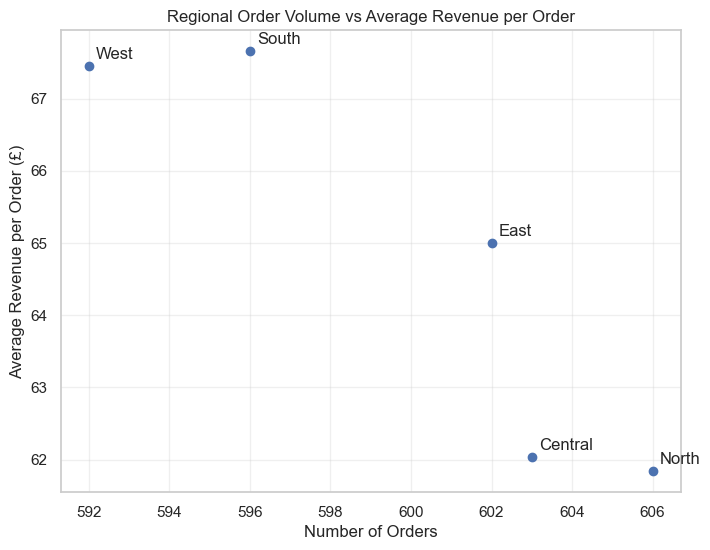

In [115]:
# 6.1.6 Regional order volume vs average order revenue

region_chart = region_performance.reset_index()

plt.figure(figsize=(8, 6))

plt.scatter(
    region_chart["orders"],
    region_chart["avg_revenue_per_order"]
)

for _, row in region_chart.iterrows():
    plt.annotate(
        row["order_region"],
        (row["orders"], row["avg_revenue_per_order"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Regional Order Volume vs Average Revenue per Order")
plt.xlabel("Number of Orders")
plt.ylabel("Average Revenue per Order (£)")
plt.grid(True, alpha=0.3)
plt.show()

In [116]:
# 6.2.1 Customer performance by loyalty tier

loyalty_performance = (
    integrated_sales_df
    .groupby("loyalty_tier", dropna=False)
    .agg(
        orders=("order_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
)

loyalty_performance

,orders,quantity_sold,revenue
loyalty_tier,,,
Gold,1666,5011.0,109509.6190
Silver,654,1948.0,42303.0085
Bronze,614,1840.0,38391.2225
<NA>,26,71.0,1123.6925
Sllver,6,29.0,777.3595
Brnze,11,24.0,768.5360
None,9,33.0,767.2730
Gld,13,36.0,634.0590


In [117]:
# 6.2.1 Inspect loyalty tier values

integrated_sales_df["loyalty_tier"].value_counts(dropna=False)

loyalty_tier
Gold      1666
Silver     654
Bronze     615
<NA>        26
Gld         13
Brnze       11
None         9
Sllver       6
Name: count, dtype: Int64

In [118]:
# 6.2.2 Standardise loyalty tier labels

integrated_sales_df["loyalty_tier"] = (
    integrated_sales_df["loyalty_tier"]
    .replace({
        "Gld": "Gold",
        "Sllver": "Silver",
        "Brnze": "Bronze",
        "None": pd.NA
    })
)

In [119]:
# Verify loyalty tier values

integrated_sales_df["loyalty_tier"].value_counts(dropna=False)

loyalty_tier
Gold      1679
Silver     660
Bronze     626
<NA>        35
Name: count, dtype: Int64

In [120]:
# 6.2.3 Label missing loyalty tiers

integrated_sales_df["loyalty_tier"] = (
    integrated_sales_df["loyalty_tier"]
    .fillna("Unknown")
)

In [121]:
# Verify loyalty tiers

integrated_sales_df["loyalty_tier"].value_counts()

loyalty_tier
Gold       1679
Silver      660
Bronze      626
Unknown      35
Name: count, dtype: Int64

In [122]:
# 6.2.4 Loyalty tier performance

loyalty_performance = (
    integrated_sales_df
    .groupby("loyalty_tier")
    .agg(
        orders=("order_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
)

loyalty_performance

,orders,quantity_sold,revenue
loyalty_tier,,,
Gold,1679,5047.0,110143.6780
Silver,660,1977.0,43080.3680
Bronze,625,1864.0,39159.7585
Unknown,35,104.0,1890.9655


Does Gold generate more revenue simply because there are more Gold orders, or does each Gold order generate more revenue on average?

In [123]:
# 6.2.5 Average revenue per order by loyalty tier

loyalty_performance["avg_revenue_per_order"] = (
    loyalty_performance["revenue"]
    / loyalty_performance["orders"]
)

loyalty_performance[
    ["orders", "revenue", "avg_revenue_per_order"]
]

,orders,revenue,avg_revenue_per_order
loyalty_tier,,,
Gold,1679,110143.6780,65.600761
Silver,660,43080.3680,65.273285
Bronze,625,39159.7585,62.655614
Unknown,35,1890.9655,54.027586


Gold customers generate the highest total revenue primarily because they account for substantially more orders, rather than because their individual orders are materially larger than Silver customers.

In [124]:
# 6.2.6 Revenue share by loyalty tier

loyalty_performance["revenue_share"] = (
    loyalty_performance["revenue"]
    / loyalty_performance["revenue"].sum()
    * 100
)

loyalty_performance[
    ["revenue", "revenue_share"]
]

,revenue,revenue_share
loyalty_tier,,
Gold,110143.6780,56.694793
Silver,43080.3680,22.174968
Bronze,39159.7585,20.156894
Unknown,1890.9655,0.973346


In [125]:
# 6.2.7 - Next Analysis

discount_quantity = (
    integrated_sales_df
    .groupby("discount_applied", dropna=False)
    .agg(
        orders=("order_id", "count"),
        avg_quantity=("quantity", "mean"),
        total_quantity=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
)

discount_quantity

,orders,avg_quantity,total_quantity,revenue
discount_applied,,,,
0.00,479,2.958159,1414.0,39814.890
0.05,505,3.083168,1557.0,43821.600
0.10,506,2.982213,1509.0,39293.532
0.15,510,2.956863,1508.0,37199.876
0.20,482,2.997921,1442.0,34144.872
NaN,517,3.033010,1562.0,0.000


In [126]:
discount_quantity_clean = discount_quantity.dropna(
    subset=["avg_quantity"]
)

discount_quantity_clean[["avg_quantity"]]

,avg_quantity
discount_applied,
0.00,2.958159
0.05,3.083168
0.10,2.982213
0.15,2.956863
0.20,2.997921
NaN,3.033010


Discount level does not appear to have a strong relationship with quantity purchased in this dataset. The highest average quantity occurs at 5% discount rather than at the higher discount levels, while the average remains close to 3 units across all recorded discount bands.

## 6.3 Delivery Performance

Which regions and product categories experience the most delivery delays?

In [127]:
# 6.3.1 — Delivery performance by region

delivery_by_region = (
    integrated_sales_df
    .groupby("order_region", dropna=False)
    .agg(
        orders=("order_id", "count"),
        delayed_orders=("is_late", "sum")
    )
)

delivery_by_region["delay_rate"] = (
    delivery_by_region["delayed_orders"]
    / delivery_by_region["orders"]
    * 100
)

delivery_by_region.sort_values("delay_rate", ascending=False)

,orders,delayed_orders,delay_rate
order_region,,,
East,602,251,41.694352
North,606,238,39.273927
Central,603,235,38.971808
South,596,230,38.590604
West,592,220,37.162162


In [128]:
# 6.3.2 — Delivery performance by product category

delivery_by_category = (
    integrated_sales_df
    .groupby("category", dropna=False)
    .agg(
        orders=("order_id", "count"),
        delayed_orders=("is_late", "sum")
    )
)

delivery_by_category["delay_rate"] = (
    delivery_by_category["delayed_orders"]
    / delivery_by_category["orders"]
    * 100
)

delivery_by_category.sort_values("delay_rate", ascending=False)

,orders,delayed_orders,delay_rate
category,,,
Personal Care,302,125,41.390728
Cleaning,1204,496,41.196013
Kitchen,403,163,40.44665
<NA>,5,2,40.0
Outdoors,508,189,37.204724
Storage,577,199,34.488735


In [129]:
# 6.4 Customer signup timing and purchasing behaviour

days_to_order_summary = (
    integrated_sales_df["days_to_order"]
    .describe()
)

days_to_order_summary

count    2943.000000
mean      192.527693
std       102.254454
min         0.000000
25%       112.000000
50%       195.000000
75%       279.000000
max       365.000000
Name: days_to_order, dtype: float64

In [130]:
# 6.4.1 - Create purchasing-time bands

integrated_sales_df["purchase_timing"] = pd.cut(
    integrated_sales_df["days_to_order"],
    bins=[-1, 90, 180, 270, 365],
    labels=["Early", "Developing", "Established", "Long-term"]
)

In [131]:
integrated_sales_df["purchase_timing"].value_counts(
    dropna=False
).sort_index()

purchase_timing
Early          609
Developing     716
Established    788
Long-term      830
NaN             57
Name: count, dtype: int64

Purchase timing bands: Orders were grouped into four periods based on days from customer signup to order. The first bin starts at -1 so that same-day purchases (days_to_order = 0) are included in the Early category.

In [132]:
# 6.4.2 — Purchasing behaviour by signup timing

purchase_timing_performance = (
    integrated_sales_df
    .groupby("purchase_timing", observed=True)
    .agg(
        orders=("order_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
)

purchase_timing_performance

,orders,quantity_sold,revenue
purchase_timing,,,
Early,609,1844.0,40306.0640
Developing,715,2160.0,44851.5980
Established,788,2318.0,51663.1355
Long-term,830,2507.0,54405.9750


In [133]:
# 6.4.3 — Average revenue per order

purchase_timing_performance["avg_revenue_per_order"] = (
    purchase_timing_performance["revenue"]
    / purchase_timing_performance["orders"]
)

purchase_timing_performance[
    ["orders", "revenue", "avg_revenue_per_order"]
]

,orders,revenue,avg_revenue_per_order
purchase_timing,,,
Early,609,40306.0640,66.184013
Developing,715,44851.5980,62.729508
Established,788,51663.1355,65.562355
Long-term,830,54405.9750,65.549367


How does the time between customer signup and their first recorded purchase relate to initial purchasing behaviour?

In [134]:
# 6.4.3 — Identify each customer's first purchase

first_purchase_df = (
    integrated_sales_df
    .dropna(subset=["customer_id", "order_date"])
    .sort_values("order_date")
    .drop_duplicates("customer_id", keep="first")
)

In [135]:
first_purchase_df.shape

(499, 27)

In [140]:
first_purchase_df.describe()

,quantity,unit_price,order_date,discount_applied,signup_date,launch_date,base_price,revenue,days_to_order
count,498.000000,499.000000,499,396.000000,492,498,498.000000,396.000000,492.000000
mean,2.975904,29.274749,2025-07-06 00:00:00.000000256,0.101641,2024-12-23 04:43:54.146341632,2024-11-28 14:30:21.686746880,23.044940,79.028455,194.802846
min,1.000000,8.640000,2025-07-06 00:00:00,0.000000,2024-07-06 00:00:00,2024-07-15 00:00:00,6.080000,7.504000,0.000000
25%,2.000000,19.805000,2025-07-06 00:00:00,0.050000,2024-09-29 00:00:00,2024-08-14 00:00:00,14.670000,36.198000,112.750000
50%,3.000000,28.690000,2025-07-06 00:00:00,0.100000,2024-12-18 00:00:00,2024-10-20 00:00:00,23.230000,66.419250,200.000000
75%,4.000000,39.890000,2025-07-06 00:00:00,0.150000,2025-03-15 06:00:00,2025-03-15 00:00:00,31.960000,115.983750,280.000000
max,5.000000,49.980000,2025-07-06 00:00:00,0.200000,2025-07-06 00:00:00,2025-06-17 00:00:00,39.210000,249.150000,365.000000
std,1.426757,12.120089,NaN,0.070915,NaN,NaN,10.166145,52.099900,102.736131


In [141]:
customer_order_counts = (
    integrated_sales_df
    .dropna(subset=["customer_id"])
    .groupby("customer_id")
    .size()
)

customer_order_counts.value_counts().sort_index()

1     10
2     21
3     37
4     73
5     86
6     76
7     74
8     44
9     33
10    20
11    17
12     4
13     2
14     1
15     1
Name: count, dtype: int64

In [144]:
# Identify minimum order per day, make first transaction

first_order_dates = (
    integrated_sales_df
    .dropna(subset=["customer_id", "order_date"])
    .groupby("customer_id")["order_date"]
    .min()
)

In [145]:
first_purchase_dates = (
    integrated_sales_df
    .dropna(subset=["customer_id", "order_date"])
    .groupby("customer_id", as_index=False)
    .agg(
        first_order_date=("order_date", "min")
    )
)

first_purchase_dates.head()

,customer_id,first_order_date
0,C00001,2025-07-06
1,C00002,2025-07-06
2,C00003,2025-07-06
3,C00004,2025-07-06
4,C00005,2025-07-06


In [146]:
# 6.4.3 — Calculate first-purchase timing
first_purchase_customer = (
    integrated_sales_df
    .dropna(subset=["customer_id", "order_date", "signup_date"])
    .groupby("customer_id", as_index=False)
    .agg(
        first_order_date=("order_date", "min"),
        signup_date=("signup_date", "first")
    )
)

In [147]:
first_purchase_customer["days_to_first_order"] = (
    first_purchase_customer["first_order_date"]
    - first_purchase_customer["signup_date"]
).dt.days

In [148]:
first_purchase_customer["days_to_first_order"].describe()

count    492.000000
mean     194.802846
std      102.736131
min        0.000000
25%      112.750000
50%      200.000000
75%      280.000000
max      365.000000
Name: days_to_first_order, dtype: float64

In [149]:
# 6.4.4 — First-purchase timing bands

first_purchase_customer["purchase_timing"] = pd.cut(
    first_purchase_customer["days_to_first_order"],
    bins=[-1, 90, 180, 270, 365],
    labels=["Early", "Developing", "Established", "Long-term"]
)

In [150]:
first_purchase_customer["purchase_timing"].value_counts(
    dropna=False
).sort_index()

purchase_timing
Early          103
Developing     113
Established    132
Long-term      144
Name: count, dtype: int64

In [151]:
# 6.4.5 — Compare first-purchase value by timing

first_order_dates = (
    integrated_sales_df
    .dropna(subset=["customer_id", "order_date"])
    .groupby("customer_id", as_index=False)
    .agg(
        first_order_date=("order_date", "min")
    )
)

In [152]:
first_day_orders = integrated_sales_df.merge(
    first_order_dates,
    on="customer_id",
    how="inner"
)

In [158]:
first_day_orders = first_day_orders[
    first_day_orders["order_date"] == first_day_orders["first_order_date"]
]

In [159]:
first_day_customer = (
    first_day_orders
    .groupby("customer_id", as_index=False)
    .agg(
        first_order_date=("first_order_date", "first"),
        quantity=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
)

In [160]:
first_day_customer = first_day_customer.merge(
    first_purchase_customer[
        ["customer_id", "days_to_first_order", "purchase_timing"]
    ],
    on="customer_id",
    how="left"
)

In [161]:
first_day_customer.head()

,customer_id,first_order_date,quantity,revenue,days_to_first_order,purchase_timing
0,C00001,2025-07-06,29.0,645.9215,71.0,Early
1,C00002,2025-07-06,20.0,511.9830,329.0,Long-term
2,C00003,2025-07-06,8.0,234.3170,52.0,Early
3,C00004,2025-07-06,15.0,349.5790,22.0,Early
4,C00005,2025-07-06,11.0,174.4420,65.0,Early


In [162]:
# 6.4.6 — First-day purchasing behaviour by timing
first_day_timing_performance = (
    first_day_customer
    .groupby("purchase_timing", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_quantity=("quantity", "mean"),
        avg_revenue=("revenue", "mean"),
        total_revenue=("revenue", "sum")
    )
)

first_day_timing_performance

,customers,avg_quantity,avg_revenue,total_revenue
purchase_timing,,,,
Early,103,17.902913,391.321010,40306.0640
Developing,113,19.115044,396.916796,44851.5980
Established,132,17.560606,391.387390,51663.1355
Long-term,144,17.409722,377.819271,54405.9750


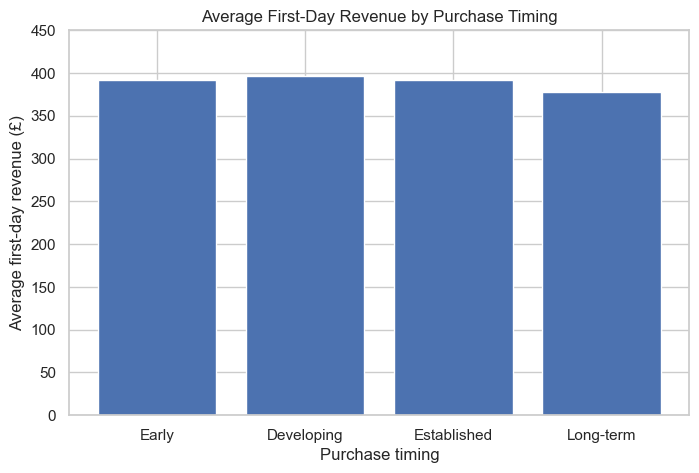

In [164]:
# 6.4.7 — Average first-day revenue by purchase timing

timing_chart = first_day_timing_performance.reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    timing_chart["purchase_timing"],
    timing_chart["avg_revenue"]
)

plt.title("Average First-Day Revenue by Purchase Timing")
plt.xlabel("Purchase timing")
plt.ylabel("Average first-day revenue (£)")
plt.ylim(0, 450)

plt.show()

Average first-day revenue remains relatively stable across signup-to-purchase timing groups. Developing customers (91–180 days) record the highest average first-day revenue, while Long-term customers (271–365 days) record the lowest. The relatively small difference between groups suggests that signup-to-first-purchase timing is not a strong differentiator of initial customer value.

In [165]:
# 6.5 — Underperforming Orders

underperforming_summary = (
    integrated_sales_df["underperforming"]
    .value_counts(dropna=False)
)

underperforming_summary

underperforming
False    2845
True      154
<NA>        1
Name: count, dtype: Int64

In [166]:
# 6.5.2 — Where are the underperforming orders occurring?

underperforming_by_category = (
    integrated_sales_df
    .groupby("category", dropna=False)
    .agg(
        orders=("order_id", "count"),
        underperforming_orders=("underperforming", "sum")
    )
)

underperforming_by_category["underperformance_rate"] = (
    underperforming_by_category["underperforming_orders"]
    / underperforming_by_category["orders"]
    * 100
)

underperforming_by_category.sort_values(
    "underperformance_rate",
    ascending=False
)

,orders,underperforming_orders,underperformance_rate
category,,,
Cleaning,1204,72,5.980066
Kitchen,403,21,5.210918
Personal Care,302,14,4.635762
Outdoors,508,23,4.527559
Storage,577,24,4.159445
<NA>,5,0,0.0


In [167]:
# 6.5.3 — Where are these problematic orders geographically?
underperforming_by_region = (
    integrated_sales_df
    .groupby("order_region", dropna=False)
    .agg(
        orders=("order_id", "count"),
        underperforming_orders=("underperforming", "sum")
    )
)

underperforming_by_region["underperformance_rate"] = (
    underperforming_by_region["underperforming_orders"]
    / underperforming_by_region["orders"]
    * 100
)

underperforming_by_region.sort_values(
    "underperformance_rate",
    ascending=False
)

,orders,underperforming_orders,underperformance_rate
order_region,,,
North,606,35,5.775578
Central,603,33,5.472637
East,602,31,5.149502
South,596,30,5.033557
West,592,25,4.222973


In [168]:
# 6.5.4 — Category and region interaction
underperforming_category_region = (
    integrated_sales_df
    .groupby(
        ["order_region", "category"],
        dropna=False
    )
    .agg(
        orders=("order_id", "count"),
        underperforming_orders=("underperforming", "sum")
    )
)

underperforming_category_region["underperformance_rate"] = (
    underperforming_category_region["underperforming_orders"]
    / underperforming_category_region["orders"]
    * 100
)

underperforming_category_region.sort_values(
    "underperformance_rate",
    ascending=False
)

orders  underperforming_orders  \
order_region category                                        
Central      Storage           110                       9   
             Kitchen            88                       7   
             Personal Care      65                       5   
North        Cleaning          245                      18   
South        Cleaning          232                      16   
West         Cleaning          238                      16   
North        Outdoors          106                       7   
East         Outdoors           99                       6   
South        Kitchen            86                       5   
East         Personal Care      53                       3   
             Cleaning          251                      14   
North        Kitchen            80                       4   
East         Storage           124                       6   
North        Personal Care      62                       3   
West         Kitchen            75                       3   
Central      Outdoors          102                       4   
South        Personal Care      55                       2   
             Storage           112                       4   
Central      Cleaning          238                       8   
West         Outdoors           91                       3   
South        Outdoors          110                       3   
East         Kitchen            74                       2   
North        Storage           112                       3   
West         Storage           119                       2   
             Personal Care      67                       1   
East         <NA>                1                       0   
North        <NA>                1                       0   
South        <NA>                1                       0   
West         <NA>                2                       0   

                            underperformance_rate  
order_region category                              
Central      Storage                     8.181818  
             Kitchen                     7.954545  
             Personal Care               7.692308  
North        Cleaning                    7.346939  
South        Cleaning                    6.896552  
West         Cleaning                    6.722689  
North        Outdoors                    6.603774  
East         Outdoors                    6.060606  
South        Kitchen                     5.813953  
East         Personal Care               5.660377  
             Cleaning                    5.577689  
North        Kitchen                          5.0  
East         Storage                      4.83871  
North        Personal Care                4.83871  
West         Kitchen                          4.0  
Central      Outdoors                    3.921569  
South        Personal Care               3.636364  
             Storage                     3.571429  
Central      Cleaning                    3.361345  
West         Outdoors                    3.296703  
South        Outdoors                    2.727273  
East         Kitchen                     2.702703  
North        Storage                     2.678571  
West         Storage                     1.680672  
             Personal Care               1.492537  
East         <NA>                             0.0  
North        <NA>                             0.0  
South        <NA>                             0.0  
West         <NA>                             0.0

In [169]:
# 6.5.4 — Focus on meaningful-volume combinations
category_region_priority = (
    underperforming_category_region[
        underperforming_category_region["orders"] >= 100
    ]
    .sort_values(
        "underperformance_rate",
        ascending=False
    )
)

category_region_priority

orders  underperforming_orders  underperformance_rate
order_region category                                                       
Central      Storage      110                       9               8.181818
North        Cleaning     245                      18               7.346939
South        Cleaning     232                      16               6.896552
West         Cleaning     238                      16               6.722689
North        Outdoors     106                       7               6.603774
East         Cleaning     251                      14               5.577689
             Storage      124                       6                4.83871
Central      Outdoors     102                       4               3.921569
South        Storage      112                       4               3.571429
Central      Cleaning     238                       8               3.361345
South        Outdoors     110                       3               2.727273
North        Storage      112                       3               2.678571
West         Storage      119                       2               1.680672

Underperformance is concentrated in specific region–category combinations rather than being evenly distributed. Central–Storage has the highest rate among sufficiently large groups, while North–Cleaning represents the strongest operational priority because it combines a high underperformance rate with the largest number of flagged orders.

In [170]:
# 6.5.5 - identify which products are responsible for the 154 underperforming orders.
underperforming_products = (
    integrated_sales_df[
        integrated_sales_df["underperforming"] == True
    ]
    .groupby("product_name")
    .agg(
        underperforming_orders=("underperforming", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values(
        "underperforming_orders",
        ascending=False
    )
)

underperforming_products.head(10)

,underperforming_orders,revenue
product_name,,
Cleaning Product 70,9,353.9485
Cleaning Product 40,9,355.6945
Cleaning Product 82,9,291.4835
Cleaning Product 53,7,201.0140
Cleaning Product 69,7,227.0740
Cleaning Product 29,7,257.3400
Storage Product 47,7,258.3280
Kitchen Product 82,7,240.2130
Cleaning Product 16,6,247.9430


Cleaning products are disproportionately represented among the products associated with underperforming orders. Three Cleaning products each recorded nine flagged orders, while seven of the top ten products belonged to the Cleaning category. These products warrant further investigation into discounting and delivery performance.

## 6.6 Key Findings and Business Insights

* Cleaning was the strongest revenue-generating category, contributing £75.4k (38.92%) of identified-category revenue.

* South recorded the highest average revenue per order at £67.66, while North and Central had relatively high order volumes but lower order values.

* Gold customers contributed 56.69% of recorded loyalty-tier revenue, largely reflecting their larger customer/order base.

* Discounting showed no clear relationship with purchase quantity, with average quantities remaining close to three units across recorded discount levels.

* East had the highest delivery delay rate at 41.69%, while Personal Care had the highest category delay rate at 41.39%.

* 154 orders (5.13%) met the analytical underperformance criteria, with North–Cleaning emerging as an important operational priority.

* Signup-to-first-recorded-order timing showed no clear evidence that longer waiting periods resulted in higher-value first purchases.

**Overall Insight:**
The analysis identifies Cleaning as a key revenue driver, while delivery performance, discount effectiveness and specific region–category combinations provide the main areas for further investigation.

## 6.7 Business Recommendations
1. Protect and strengthen Cleaning performance through inventory planning, supplier management and availability monitoring.
   
2. Investigate delivery delays, particularly in East and within Personal Care and Cleaning.

3. Prioritise North–Cleaning for deeper operational review due to its elevated underperformance rate.

4. Review discount effectiveness rather than assuming higher discounts generate higher quantities.

5. Monitor customer conversion timing and test strategies that encourage earlier first purchases.
